# 01_prepare_eda

Мы начинаем с разведочного анализа данных, потому что без него сложно осмысленно обсуждать
и baseline-модели, и более сложные подходы. В задаче прогнозирования спроса важно не просто увидеть,
какие таблицы доступны, но и понять, насколько они полны, как связаны между собой и какие ограничения
накладывают на будущие эксперименты.

В этом ноутбуке нужно решить две связанные задачи. С одной стороны, содержательно посмотреть на данные:
что представляет собой обучающая и тестовая выборки, какие внешние факторы доступны,
насколько отличаются категории товаров и магазины. С другой стороны, уже на этом этапе собрать
единую и аккуратно подготовленную таблицу, которая потом будет использоваться в моделях.


In [2]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import acf

sns.set_theme(style='whitegrid', palette='deep', font_scale=1.1)
pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 140)
plt.rcParams['figure.figsize'] = (16, 7)

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [
        cwd,
        cwd.parent,
        cwd / 'project',
        cwd.parent / 'project',
    ]
    for candidate in candidates:
        if (candidate / 'data' / 'raw').exists() and (candidate / 'artifacts').exists():
            return candidate
    raise FileNotFoundError(
        f'Не удалось определить PROJECT_ROOT из cwd={cwd}. '
        'Ожидается каталог с подпапками data/raw и artifacts.'
    )

def read_csv_checked(path: Path, parse_dates=None, **kwargs):
    header = pd.read_csv(path, nrows=0)
    parse_dates = parse_dates or []
    missing_cols = [col for col in parse_dates if col not in header.columns]
    if missing_cols:
        raise ValueError(
            f"В файле {path} нет колонок {missing_cols}. Найдены колонки: {list(header.columns)}"
        )
    return pd.read_csv(path, parse_dates=parse_dates, **kwargs)

PROJECT_ROOT = resolve_project_root()
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
DATASETS_DIR = ARTIFACTS_DIR / 'datasets'
METADATA_DIR = ARTIFACTS_DIR / 'metadata'

print('CWD:', Path.cwd().resolve())
print('PROJECT_ROOT:', PROJECT_ROOT)
print('RAW_DATA_DIR:', RAW_DATA_DIR)
print('ARTIFACTS_DIR:', ARTIFACTS_DIR)
print('DATASETS_DIR:', DATASETS_DIR)
print('METADATA_DIR:', METADATA_DIR)

for path in [DATASETS_DIR, METADATA_DIR]:
    path.mkdir(parents=True, exist_ok=True)

train_raw = read_csv_checked(RAW_DATA_DIR / 'train.csv', parse_dates=['date'])
test_raw = read_csv_checked(RAW_DATA_DIR / 'test.csv', parse_dates=['date'])
stores_df = read_csv_checked(RAW_DATA_DIR / 'stores.csv')
oil_df = read_csv_checked(RAW_DATA_DIR / 'oil.csv', parse_dates=['date'])
holidays_df = read_csv_checked(RAW_DATA_DIR / 'holidays_events.csv', parse_dates=['date'])
transactions_df = read_csv_checked(RAW_DATA_DIR / 'transactions.csv', parse_dates=['date'])


CWD: /home/jupyter/project/demand_forecasting/notebooks
PROJECT_ROOT: /home/jupyter/project/demand_forecasting
RAW_DATA_DIR: /home/jupyter/project/demand_forecasting/data/raw
ARTIFACTS_DIR: /home/jupyter/project/demand_forecasting/artifacts
DATASETS_DIR: /home/jupyter/project/demand_forecasting/artifacts/datasets
METADATA_DIR: /home/jupyter/project/demand_forecasting/artifacts/metadata


## 1. Что у нас вообще есть на руках

Сначала спокойно посмотрим на все исходные таблицы. Здесь важно не торопиться с моделированием,
а зафиксировать масштаб задачи: временной интервал, количество наблюдений, роль каждого набора данных
и то, какую информацию мы потенциально сможем превратить в признаки.


In [3]:
raw_overview = pd.DataFrame([
    {
        'dataset': 'train_raw',
        'rows': len(train_raw),
        'cols': train_raw.shape[1],
        'date_min': train_raw['date'].min(),
        'date_max': train_raw['date'].max(),
    },
    {
        'dataset': 'test_raw',
        'rows': len(test_raw),
        'cols': test_raw.shape[1],
        'date_min': test_raw['date'].min(),
        'date_max': test_raw['date'].max(),
    },
    {'dataset': 'stores', 'rows': len(stores_df), 'cols': stores_df.shape[1], 'date_min': pd.NaT, 'date_max': pd.NaT},
    {'dataset': 'oil', 'rows': len(oil_df), 'cols': oil_df.shape[1], 'date_min': oil_df['date'].min(), 'date_max': oil_df['date'].max()},
    {'dataset': 'holidays', 'rows': len(holidays_df), 'cols': holidays_df.shape[1], 'date_min': holidays_df['date'].min(), 'date_max': holidays_df['date'].max()},
    {'dataset': 'transactions', 'rows': len(transactions_df), 'cols': transactions_df.shape[1], 'date_min': transactions_df['date'].min(), 'date_max': transactions_df['date'].max()},
])
raw_overview


,dataset,rows,cols,date_min,date_max
0,train_raw,3000888,6,2013-01-01,2017-08-15
1,test_raw,28512,5,2017-08-16,2017-08-31
2,stores,54,5,NaT,NaT
3,oil,1218,2,2013-01-01,2017-08-31
4,holidays,350,6,2012-03-02,2017-12-26
5,transactions,83488,3,2013-01-01,2017-08-15


### Что стоит отметить после просмотра таблиц

После выполнения блока ниже имеет смысл коротко зафиксировать,
насколько набор данных выглядит полным и нет ли на первом же шаге странностей по размерам таблиц,
временным промежуткам или назначению источников.

Уже на первом шаге видно, что перед нами не один временной ряд, а большая панель из 54 магазинов и 33 товарных семейств,
то есть 1 782 параллельных рядов с общей длиной более 3 млн наблюдений в обучении. Тест покрывает фиксированный горизонт
с 2017-08-16 по 2017-08-31 и по структуре согласован с train. Это важное наблюдение: задача изначально имеет выраженную иерархию
по магазину, категории, календарю и внешним факторам, поэтому сильная модель должна уметь либо переносить информацию между рядами,
либо очень аккуратно выбирать уровень агрегирования.


## 2. Полнота train/test и календарный каркас

Теперь переходим к принципиальному вопросу: что именно означает одна строка в наших данных.
Если в таблице есть только наблюдавшиеся продажи, то отсутствие строки еще не означает нулевой спрос.
Это важное место, потому что от него зависит вся дальнейшая постановка задачи.

Здесь мы проверяем, является ли обучающая выборка полной календарной панелью,
или же такой каркас придется восстанавливать отдельно.


In [4]:
expected_train_dates = pd.date_range(train_raw['date'].min(), train_raw['date'].max(), freq='D')
expected_test_dates = pd.date_range(test_raw['date'].min(), test_raw['date'].max(), freq='D')
train_expected_grid = train_raw['store_nbr'].nunique() * train_raw['family'].nunique() * len(expected_train_dates)
test_expected_grid = test_raw['store_nbr'].nunique() * test_raw['family'].nunique() * len(expected_test_dates)

integrity_summary = pd.DataFrame([
    {
        'dataset': 'train_raw',
        'rows_actual': len(train_raw),
        'rows_expected_grid': train_expected_grid,
        'duplicate_keys': train_raw[['date', 'store_nbr', 'family']].duplicated().sum(),
        'missing_dates_count': len(set(expected_train_dates) - set(train_raw['date'].unique())),
    },
    {
        'dataset': 'test_raw',
        'rows_actual': len(test_raw),
        'rows_expected_grid': test_expected_grid,
        'duplicate_keys': test_raw[['date', 'store_nbr', 'family']].duplicated().sum(),
        'missing_dates_count': len(set(expected_test_dates) - set(test_raw['date'].unique())),
    },
])
integrity_summary


,dataset,rows_actual,rows_expected_grid,duplicate_keys,missing_dates_count
0,train_raw,3000888,3008016,0,1688
1,test_raw,28512,28512,0,16


In [5]:
missing_train_dates = sorted(set(expected_train_dates) - set(train_raw['date'].unique()))
missing_test_dates = sorted(set(expected_test_dates) - set(test_raw['date'].unique()))

print('Пропущенные даты в train_raw:', missing_train_dates[:10], '...' if len(missing_train_dates) > 10 else '')
print('Пропущенные даты в test_raw:', missing_test_dates[:10], '...' if len(missing_test_dates) > 10 else '')

train_raw.isna().sum().sort_values(ascending=False).to_frame('missing_train')


Пропущенные даты в train_raw: [Timestamp('2013-01-01 00:00:00', freq='D'), Timestamp('2013-01-02 00:00:00', freq='D'), Timestamp('2013-01-03 00:00:00', freq='D'), Timestamp('2013-01-04 00:00:00', freq='D'), Timestamp('2013-01-05 00:00:00', freq='D'), Timestamp('2013-01-06 00:00:00', freq='D'), Timestamp('2013-01-07 00:00:00', freq='D'), Timestamp('2013-01-08 00:00:00', freq='D'), Timestamp('2013-01-09 00:00:00', freq='D'), Timestamp('2013-01-10 00:00:00', freq='D')] ...
Пропущенные даты в test_raw: [Timestamp('2017-08-16 00:00:00', freq='D'), Timestamp('2017-08-17 00:00:00', freq='D'), Timestamp('2017-08-18 00:00:00', freq='D'), Timestamp('2017-08-19 00:00:00', freq='D'), Timestamp('2017-08-20 00:00:00', freq='D'), Timestamp('2017-08-21 00:00:00', freq='D'), Timestamp('2017-08-22 00:00:00', freq='D'), Timestamp('2017-08-23 00:00:00', freq='D'), Timestamp('2017-08-24 00:00:00', freq='D'), Timestamp('2017-08-25 00:00:00', freq='D')] ...


,missing_train
id,0
date,0
store_nbr,0
family,0
sales,0
onpromotion,0


### Промежуточный вывод по полноте данных

После выполнения ячеек выше здесь стоит коротко записать,
есть ли пропущенные даты, совпадает ли фактический размер train/test
с ожидаемой полной сеткой и действительно ли нужно восстанавливать полный календарный каркас.

Проверка полноты показывает, что `train_raw` не является полной календарной панелью: относительно ожидаемой сетки не хватает 7 128 строк,
а в самом временном индексе отсутствуют 4 даты. Для `test_raw` такой проблемы нет: его размер полностью совпадает с ожидаемой сеткой.
С методологической точки зрения это критично. Отсутствующая строка здесь не равна автоматически пропуску данных и тем более не равна автоматически ошибке:
для части комбинаций это может означать неявно нулевые продажи. Поэтому восстановление полной панели нужно не ради удобства,
а ради корректной постановки задачи, лаговых признаков и честного сравнения моделей.


## 3. Справочники и внешние источники

Дальше отдельно посмотрим на справочники и внешние таблицы.
Обычно именно здесь появляются будущие сложности моделирования:
неоднозначные ключи для объединения, пропуски, дубли и признаки,
которые хорошо выглядят в анализе, но позже оказываются трудными для практического использования.


In [6]:
stores_profile = {
    'missing_values': stores_df.isna().sum().sum(),
    'duplicate_store_nbr': stores_df[['store_nbr']].duplicated().sum(),
    'n_cities': stores_df['city'].nunique(),
    'n_states': stores_df['state'].nunique(),
    'n_store_types': stores_df['type'].nunique(),
    'n_clusters': stores_df['cluster'].nunique(),
}

holidays_profile = {
    'rows': len(holidays_df),
    'duplicate_full_rows': holidays_df[['date', 'locale', 'type', 'locale_name', 'description']].duplicated().sum(),
    'duplicate_dates': holidays_df[['date']].duplicated().sum(),
    'n_locales': holidays_df['locale'].nunique(),
    'n_types': holidays_df['type'].nunique(),
}

oil_profile = {
    'rows': len(oil_df),
    'missing_dcoilwtico': int(oil_df['dcoilwtico'].isna().sum()),
    'date_min': oil_df['date'].min(),
    'date_max': oil_df['date'].max(),
}

transactions_profile = {
    'rows': len(transactions_df),
    'duplicate_keys': transactions_df[['date', 'store_nbr']].duplicated().sum(),
    'missing_values': transactions_df.isna().sum().sum(),
}

pd.DataFrame([
    {'table': 'stores', **stores_profile},
    {'table': 'holidays', **holidays_profile},
    {'table': 'oil', **oil_profile},
    {'table': 'transactions', **transactions_profile},
])


,table,missing_values,duplicate_store_nbr,n_cities,n_states,n_store_types,n_clusters,rows,duplicate_full_rows,duplicate_dates,n_locales,n_types,missing_dcoilwtico,date_min,date_max,duplicate_keys
0,stores,0.0,0.0,22.0,16.0,5.0,17.0,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN
1,holidays,NaN,NaN,NaN,NaN,NaN,NaN,350.0,0.0,38.0,3.0,6.0,NaN,NaT,NaT,NaN
2,oil,NaN,NaN,NaN,NaN,NaN,NaN,1218.0,NaN,NaN,NaN,NaN,43.0,2013-01-01,2017-08-31,NaN
3,transactions,0.0,NaN,NaN,NaN,NaN,NaN,83488.0,NaN,NaN,NaN,NaN,NaN,NaT,NaT,0.0


In [7]:
stores_df['type'].value_counts().to_frame('n_stores_by_type')


,n_stores_by_type
D,18
C,15
A,9
B,8
E,4


In [8]:
holidays_df[['locale', 'type']].value_counts().to_frame('n_events').head(20)


n_events
locale   type                
Local    Holiday          137
National Holiday           60
         Event             56
         Additional        40
Regional Holiday           24
Local    Additional        11
National Transfer           8
         Bridge             5
         Work Day           5
Local    Transfer           4

In [9]:
oil_missing_by_weekday = oil_df.assign(weekday=oil_df['date'].dt.day_name())['weekday'][oil_df['dcoilwtico'].isna()].value_counts()
oil_missing_by_weekday.to_frame('missing_dcoilwtico')


,missing_dcoilwtico
Monday,23
Friday,9
Thursday,7
Tuesday,2
Wednesday,2


### Промежуточный вывод по справочникам и внешним данным

После просмотра магазинов, праздников, нефти и транзакций здесь полезно зафиксировать,
какие таблицы выглядят чистыми, а какие потребуют более аккуратной обработки и осторожной интерпретации.

По качеству данных `stores` и `transactions` выглядят чистыми, но по смыслу признаки ведут себя очень по-разному. `stores` — это стабильный справочник,
который безопасно присоединять как метаданные магазина. `holidays_events` тоже полезен, но это не просто таблица праздничных дат:
в ней есть перенесённые праздники, `Bridge`, `Work Day`, дополнительные события и описания, которые нужно интерпретировать семантически,
а не как обычный бинарный календарь. Отдельно важно, что один и тот же день иногда несёт сразу несколько событий разного масштаба,
поэтому праздничные признаки нужно агрегировать по понятным правилам. Кроме того, в текстовых описаниях встречаются события вроде землетрясения,
а значит `description` потенциально может содержать слишком сильный событийный сигнал и требует осторожности как признак.
Таблица `oil` содержит 43 пропуска по `dcoilwtico`, что согласуется с нерабочими днями рынка; при этом нефть присутствует и на тестовом горизонте,
значит после аккуратной обработки это потенциально доступный внешний фактор. Совсем другой статус у `transactions`: это сильный описательный показатель
магазинного трафика, но он доступен только в train и отсутствует в test, поэтому как прямой признак для итогового прогноза его можно использовать
только в рамках отдельной двухэтапной схемы с собственным прогнозом транзакций.


## 4. Подготовка полной train-панели и обогащение признаками

На этом шаге анализ переходит в подготовку данных. Из исходного ноутбука сохраняем важную идею:
обучающую выборку нужно привести к полной календарной панели, чтобы отсутствие наблюдения
не ломало дальнейшие лаги, rolling-статистики и baseline-оценки.

Одновременно здесь же собираем единую таблицу признаков,
объединяя продажи с характеристиками магазинов, календарем событий и внешними факторами.


In [10]:
CATEGORY_MAP = {
    'Праздник': ['Carnaval', 'Navidad', 'Navidad-1', 'Navidad-2', 'Navidad-3', 'Navidad-4', 'Navidad+1', 'Dia de la Madre', 'Dia de la Madre-1', 'Dia del Trabajo', 'Dia de Difuntos', 'Viernes Santo', 'Primer dia del ano', 'Primer dia del ano-1'],
    'Основание': ['Fundacion de Cuenca', 'Fundacion de Ibarra', 'Fundacion de Quito', 'Fundacion de Quito-1', 'Fundacion de Manta', 'Fundacion de Loja', 'Fundacion de Santo Domingo', 'Fundacion de Machala', 'Fundacion de Esmeraldas', 'Fundacion de Riobamba', 'Fundacion de Ambato', 'Fundacion de Guayaquil', 'Fundacion de Guayaquil-1', 'Provincializacion de Santo Domingo', 'Provincializacion Santa Elena', 'Provincializacion de Cotopaxi', 'Provincializacion de Imbabura', 'Cantonizacion de Salinas', 'Cantonizacion de Libertad', 'Cantonizacion de Riobamba', 'Cantonizacion del Puyo', 'Cantonizacion de Guaranda', 'Cantonizacion de Latacunga', 'Cantonizacion de El Carmen', 'Cantonizacion de Cayambe', 'Cantonizacion de Quevedo'],
    'Независимость/История': ['Independencia de Guaranda', 'Independencia de Latacunga', 'Independencia de Ambato', 'Independencia de Cuenca', 'Independencia de Guayaquil', 'Primer Grito de Independencia', 'Batalla de Pichincha'],
    'Глобальные распродажи': ['Black Friday', 'Cyber Monday'],
    'Футбол': ['Mundial de futbol Brasil: Octavos de Final', 'Mundial de futbol Brasil: Cuartos de Final', 'Mundial de futbol Brasil: Semifinales', 'Inauguracion Mundial de futbol Brasil', 'Mundial de futbol Brasil: Ecuador-Suiza', 'Mundial de futbol Brasil: Ecuador-Honduras', 'Mundial de futbol Brasil: Ecuador-Francia', 'Mundial de futbol Brasil: Tercer y cuarto lugar', 'Mundial de futbol Brasil: Final'],
    'Землетрясение': ['Terremoto Manabi', 'Terremoto Manabi+1', 'Terremoto Manabi+2', 'Terremoto Manabi+3', 'Terremoto Manabi+4', 'Terremoto Manabi+5', 'Terremoto Manabi+6', 'Terremoto Manabi+7', 'Terremoto Manabi+8', 'Terremoto Manabi+9', 'Terremoto Manabi+10', 'Terremoto Manabi+11', 'Terremoto Manabi+12', 'Terremoto Manabi+13', 'Terremoto Manabi+14', 'Terremoto Manabi+15', 'Terremoto Manabi+16', 'Terremoto Manabi+17', 'Terremoto Manabi+18', 'Terremoto Manabi+19', 'Terremoto Manabi+20', 'Terremoto Manabi+21', 'Terremoto Manabi+22', 'Terremoto Manabi+23', 'Terremoto Manabi+24', 'Terremoto Manabi+25', 'Terremoto Manabi+26', 'Terremoto Manabi+27', 'Terremoto Manabi+28', 'Terremoto Manabi+29', 'Terremoto Manabi+30'],
    'Переносы': ['Traslado Independencia de Guayaquil', 'Traslado Primer Grito de Independencia', 'Traslado Batalla de Pichincha', 'Traslado Fundacion de Guayaquil', 'Traslado Fundacion de Quito', 'Traslado Primer dia del ano', 'Puente Navidad', 'Puente Primer dia del ano', 'Puente Dia de Difuntos', 'Recupero puente primer dia del ano', 'Recupero Puente Dia de Difuntos', 'Recupero Puente Navidad', 'Recupero Puente Primer dia del ano', 'Recupero puente Navidad'],
}

def recode_event(event):
    for category, events in CATEGORY_MAP.items():
        if event in events:
            return category
    return 'Другое'


def build_full_train_panel(train_df):
    all_dates = pd.date_range(train_df['date'].min(), train_df['date'].max(), freq='D')
    all_stores = np.sort(train_df['store_nbr'].unique())
    all_families = np.sort(train_df['family'].unique())
    full_index = pd.MultiIndex.from_product([all_dates, all_stores, all_families], names=['date', 'store_nbr', 'family'])
    full_df = pd.DataFrame(index=full_index).reset_index()
    out = full_df.merge(train_df, on=['date', 'store_nbr', 'family'], how='left')
    out = out.drop(columns=['id'], errors='ignore')
    out['sales'] = out['sales'].fillna(0.0)
    out['onpromotion'] = out['onpromotion'].fillna(0)
    return out


def prepare_oil(oil_raw):
    oil = oil_raw[['date', 'dcoilwtico']].drop_duplicates().sort_values('date').set_index('date')
    oil = oil.asfreq('D')
    oil['dcoilwtico'] = oil['dcoilwtico'].interpolate(method='time').ffill().bfill()
    return oil.reset_index()


def prepare_holidays(holidays_raw):
    holidays = holidays_raw.copy()
    holidays['agg_description'] = holidays['description'].apply(recode_event)
    holidays = holidays.drop_duplicates()
    return holidays


def build_holiday_views(holidays):
    fields = ['type', 'locale', 'description', 'transferred', 'agg_description']
    national = holidays[holidays['locale'] == 'National'][['date'] + fields].drop_duplicates('date')
    national = national.rename(columns={c: f'{c}_national' for c in fields})
    regional = holidays[holidays['locale'] == 'Regional'][['date', 'locale_name'] + fields].drop_duplicates(['date', 'locale_name'])
    regional = regional.rename(columns={'locale_name': 'state', **{c: f'{c}_regional' for c in fields}})
    local = holidays[holidays['locale'] == 'Local'][['date', 'locale_name'] + fields].drop_duplicates(['date', 'locale_name'])
    local = local.rename(columns={'locale_name': 'city', **{c: f'{c}_local' for c in fields}})
    return national, regional, local


def enrich_frame(df, stores, oil, holidays, transactions=None, is_train=True):
    out = df.copy()
    out = out.merge(stores.rename(columns={'type': 'store_type'}), on='store_nbr', how='left')
    out = out.merge(oil, on='date', how='left')
    national, regional, local = build_holiday_views(holidays)
    out = out.merge(national, on='date', how='left')
    out = out.merge(regional, on=['date', 'state'], how='left')
    out = out.merge(local, on=['date', 'city'], how='left')
    for field in ['type', 'locale', 'description', 'transferred', 'agg_description']:
        out[field] = out.get(f'{field}_national').fillna(out.get(f'{field}_regional')).fillna(out.get(f'{field}_local'))
    out['type'] = out['type'].fillna('Work Day')
    out['locale'] = out['locale'].fillna('None')
    out['description'] = out['description'].fillna('None')
    out['agg_description'] = out['agg_description'].fillna('None')
    out['transferred'] = out['transferred'].fillna(False)
    out['is_holiday'] = (out['type'].isin(['Holiday', 'Transfer', 'Bridge']) & (~out['transferred'].astype(bool))).astype('int8')
    out['is_payday'] = out['date'].apply(lambda x: 1 if x.day in [15, x.days_in_month] else 0).astype('int8')
    out['day_of_week'] = out['date'].dt.dayofweek.astype('int8')
    drop_cols = [col for col in out.columns if col.endswith('_national') or col.endswith('_regional') or col.endswith('_local')]
    out = out.drop(columns=drop_cols, errors='ignore')
    if is_train and transactions is not None:
        out = out.merge(transactions, on=['date', 'store_nbr'], how='left')
        out['transactions'] = out['transactions'].fillna(0.0)
    duplicates = out[['date', 'store_nbr', 'family']].duplicated().sum()
    if duplicates:
        out = out.drop_duplicates(subset=['date', 'store_nbr', 'family'])
    return out.sort_values(['store_nbr', 'family', 'date']).reset_index(drop=True)


In [11]:
train_panel = build_full_train_panel(train_raw)
oil_prepared = prepare_oil(oil_df)
holidays_prepared = prepare_holidays(holidays_df)

train_processed = enrich_frame(
    train_panel,
    stores=stores_df,
    oil=oil_prepared,
    holidays=holidays_prepared,
    transactions=transactions_df,
    is_train=True,
)

test_processed = enrich_frame(
    test_raw,
    stores=stores_df,
    oil=oil_prepared,
    holidays=holidays_prepared,
    transactions=None,
    is_train=False,
)

train_processed.to_csv(DATASETS_DIR / 'train_processed.csv', index=False)
test_processed.to_csv(DATASETS_DIR / 'test_processed.csv', index=False)

panel_growth = pd.DataFrame([
    {'stage': 'train_raw', 'rows': len(train_raw)},
    {'stage': 'train_panel_full_grid', 'rows': len(train_panel)},
    {'stage': 'train_processed', 'rows': len(train_processed)},
    {'stage': 'test_processed', 'rows': len(test_processed)},
])
panel_growth


,stage,rows
0,train_raw,3000888
1,train_panel_full_grid,3008016
2,train_processed,3008016
3,test_processed,28512


### Что важно зафиксировать после подготовки данных

Если после восстановления полной панели размер train заметно увеличился,
это значит, что в исходных продажах часть комбинаций была представлена неявно.
Это важное наблюдение, потому что без такого шага все последующие модели решали бы немного другую задачу.

После восстановления полной панели размер обучающей таблицы вырос до 3 008 016 строк, то есть ровно на те 7 128 наблюдений,
которых не хватало в исходном `train_raw`. Это подтверждает, что часть комбинаций `(date, store_nbr, family)` действительно была представлена неявно.
Для дальнейшего моделирования это означает следующее: мы теперь работаем не с выборкой только по наблюдавшимся продажам,
а с более корректной постановкой, где ассортиментная разреженность и нулевой спрос становятся частью самой задачи.


## 5. Верхнеуровневый профиль уже подготовленного train_processed

После объединения таблиц полезно еще раз посмотреть на данные уже в их рабочем виде.
Это проверка того, что после всех merge и заполнений мы не потеряли смысл признаков,
не внесли неожиданные пропуски и действительно получили пригодную для моделирования панель.


In [12]:
train_profile = {
    'date_min': train_processed['date'].min(),
    'date_max': train_processed['date'].max(),
    'n_rows': len(train_processed),
    'n_stores': train_processed['store_nbr'].nunique(),
    'n_families': train_processed['family'].nunique(),
    'n_cities': train_processed['city'].nunique(),
    'n_store_types': train_processed['store_type'].nunique(),
    'n_clusters': train_processed['cluster'].nunique(),
    'n_states': train_processed['state'].nunique(),
}
pd.Series(train_profile)


date_min         2013-01-01 00:00:00
date_max         2017-08-15 00:00:00
n_rows                       3008016
n_stores                          54
n_families                        33
n_cities                          22
n_store_types                      5
n_clusters                        17
n_states                          16
dtype: object

In [13]:
train_processed.isna().sum().sort_values(ascending=False).to_frame('missing_after_enrichment').head(20)


,missing_after_enrichment
date,0
type,0
day_of_week,0
is_payday,0
is_holiday,0
agg_description,0
transferred,0
description,0
locale,0
dcoilwtico,0


### Промежуточный вывод по итоговой обучающей таблице

Здесь стоит коротко записать, насколько цельной и удобной для моделирования выглядит итоговая таблица:
остались ли заметные пропуски, все ли ключевые признаки на месте и не появилось ли странных эффектов после объединения.

Итоговая таблица `train_processed` выглядит цельной и пригодной для моделирования, но важен именно характер оставшихся пропусков.
Поля `description`, `locale` и `agg_description` пустуют не потому, что merge выполнен плохо, а потому, что в большинстве дней
нет релевантного праздничного события. Иными словами, это структурное отсутствие события, а не дефект данных.
Одновременно таблица уже подсказывает важное разделение будущих признаков на две группы: доступные на момент прогноза (`onpromotion`, календарь, метаданные магазина, нефть)
и исследовательские признаки с ограниченной прикладной ценностью (`transactions`), которые нельзя безоговорочно переносить в финальную модель.


## 6. Связь с внешними факторами

Теперь можно посмотреть, дают ли внешние факторы хоть какой-то содержательный сигнал.
На этом этапе нас интересует не строгая причинная интерпретация,
а практический вопрос: какие признаки вообще выглядят осмысленными кандидатами
для дальнейшего прогнозирования спроса.


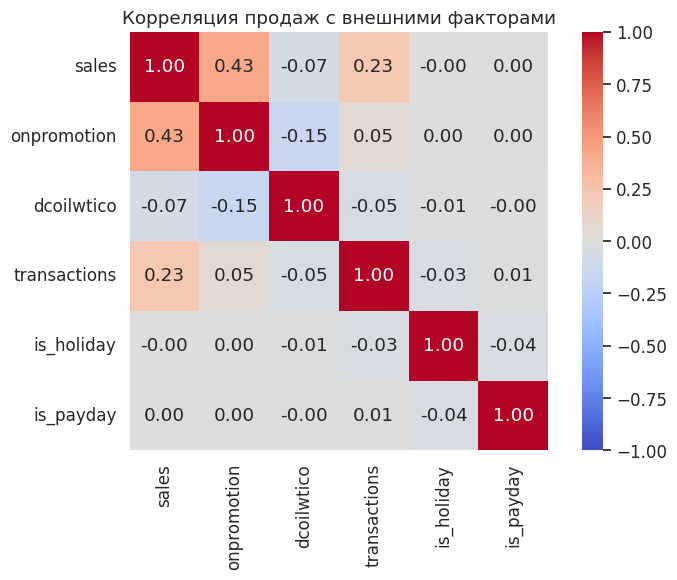

In [14]:
corr_cols = [col for col in ['sales', 'onpromotion', 'dcoilwtico', 'transactions', 'is_holiday', 'is_payday'] if col in train_processed.columns]
corr_matrix = train_processed[corr_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Корреляция продаж с внешними факторами')
plt.tight_layout()
plt.show()


In [15]:
daily_external_view = (
    train_processed.groupby('date')
    .agg({
        'sales': 'sum',
        'onpromotion': 'sum',
        'dcoilwtico': 'mean',
        'transactions': 'sum' if 'transactions' in train_processed.columns else 'mean',
        'is_holiday': 'max',
        'is_payday': 'max',
    })
    .reset_index()
)
daily_external_view.head()


,date,sales,onpromotion,dcoilwtico,transactions,is_holiday,is_payday
0,2013-01-01,2511.618999,0.0,93.140000,25410.0,1,0
1,2013-01-02,496092.417944,0.0,93.140000,3076095.0,0,0
2,2013-01-03,361461.231124,0.0,92.970000,2590632.0,0,0
3,2013-01-04,354459.677093,0.0,93.120000,2590302.0,0,0
4,2013-01-05,477350.121229,0.0,93.146667,3087909.0,0,0


### Лаговые зависимости внешних факторов

На общей корреляции легко потерять важный эффект запаздывания: часть внешних драйверов не влияет на спрос строго день в день.
Поэтому ниже мы отдельно оцениваем лаговые связи по товарным семействам и смотрим, улучшается ли сигнал для нефти и payday-флага
при сдвиге на несколько дней или недель.


In [16]:
family_daily_external = (
    train_processed.groupby(['family', 'date'])
    .agg({
        'sales': 'sum',
        'onpromotion': 'sum',
        'dcoilwtico': 'mean',
        'transactions': 'sum',
        'is_holiday': 'max',
        'is_payday': 'max',
    })
    .reset_index()
    .sort_values(['family', 'date'])
)

family_daily_external.head()


,family,date,sales,onpromotion,dcoilwtico,transactions,is_holiday,is_payday
0,AUTOMOTIVE,2013-01-01,0.0,0.0,93.140000,770.0,1,0
1,AUTOMOTIVE,2013-01-02,255.0,0.0,93.140000,93215.0,0,0
2,AUTOMOTIVE,2013-01-03,161.0,0.0,92.970000,78504.0,0,0
3,AUTOMOTIVE,2013-01-04,169.0,0.0,93.120000,78494.0,0,0
4,AUTOMOTIVE,2013-01-05,342.0,0.0,93.146667,93573.0,0,0


In [17]:
candidate_lags = range(1, 63)


def scan_lag_profile(frame, feature, lags=candidate_lags):
    rows = []
    for family, family_frame in frame.groupby('family'):
        ordered = family_frame.sort_values('date').set_index('date').asfreq('D', fill_value=0)
        sales = ordered['sales']
        feature_series = ordered[feature]

        for lag in lags:
            rows.append({
                'family': family,
                'feature': feature,
                'lag': lag,
                'corr': sales.corr(feature_series.shift(lag)),
            })

    return pd.DataFrame(rows)


lag_scan = pd.concat(
    [
        scan_lag_profile(family_daily_external, 'dcoilwtico'),
        scan_lag_profile(family_daily_external, 'is_payday'),
    ],
    ignore_index=True,
)

lag_best = (
    lag_scan.dropna(subset=['corr'])
    .assign(abs_corr=lambda df: df['corr'].abs())
    .sort_values(['feature', 'family', 'abs_corr', 'lag'], ascending=[True, True, False, True])
    .groupby(['feature', 'family'], as_index=False)
    .first()
)

oil_best = lag_best[lag_best['feature'] == 'dcoilwtico'][['family', 'lag', 'corr', 'abs_corr']].rename(
    columns={
        'lag': 'best_oil_lag',
        'corr': 'best_oil_corr',
        'abs_corr': 'best_oil_abs_corr',
    }
)
payday_best = lag_best[lag_best['feature'] == 'is_payday'][['family', 'lag', 'corr', 'abs_corr']].rename(
    columns={
        'lag': 'best_payday_lag',
        'corr': 'best_payday_corr',
        'abs_corr': 'best_payday_abs_corr',
    }
)

same_day_rows = []
for family, family_frame in family_daily_external.groupby('family'):
    payday_mean = family_frame.loc[family_frame['is_payday'] == 1, 'sales'].mean()
    non_payday_mean = family_frame.loc[family_frame['is_payday'] == 0, 'sales'].mean()

    same_day_rows.append({
        'family': family,
        'corr_transactions': family_frame['sales'].corr(family_frame['transactions']),
        'corr_onpromotion': family_frame['sales'].corr(family_frame['onpromotion']),
        'corr_holiday_same_day': family_frame['sales'].corr(family_frame['is_holiday']),
        'corr_oil_same_day': family_frame['sales'].corr(family_frame['dcoilwtico']),
        'corr_payday_same_day': family_frame['sales'].corr(family_frame['is_payday']),
        'payday_uplift_pct': 100 * (payday_mean / non_payday_mean - 1) if pd.notna(payday_mean) and pd.notna(non_payday_mean) and non_payday_mean != 0 else np.nan,
    })

same_day_summary = pd.DataFrame(same_day_rows)

lagged_external_summary = (
    same_day_summary
    .merge(oil_best, on='family', how='left')
    .merge(payday_best, on='family', how='left')
    .sort_values(['best_oil_abs_corr', 'best_payday_abs_corr'], ascending=False)
)

lagged_external_summary.head(15).round(3)


,family,corr_transactions,corr_onpromotion,corr_holiday_same_day,corr_oil_same_day,corr_payday_same_day,payday_uplift_pct,best_oil_lag,best_oil_corr,best_oil_abs_corr,best_payday_lag,best_payday_corr,best_payday_abs_corr
16,HOME AND KITCHEN II,0.411,0.513,-0.012,-0.802,0.003,0.925,1,-0.801,0.801,43,-0.021,0.021
15,HOME AND KITCHEN I,0.477,0.460,-0.009,-0.723,0.006,1.868,1,-0.721,0.721,25,-0.035,0.035
23,MAGAZINES,0.367,0.114,-0.007,-0.687,-0.007,-3.252,62,-0.720,0.720,39,0.023,0.023
30,PRODUCE,0.329,0.473,-0.020,-0.648,0.005,1.847,1,-0.646,0.646,10,-0.028,0.028
26,PET SUPPLIES,0.390,0.387,0.009,-0.642,0.003,1.163,1,-0.641,0.641,10,-0.026,0.026
18,HOME CARE,0.378,0.494,-0.001,-0.626,0.006,2.038,1,-0.624,0.624,10,-0.038,0.038
3,BEVERAGES,0.546,0.601,-0.009,-0.625,0.009,1.788,1,-0.623,0.623,10,-0.049,0.049
6,CELEBRATION,0.358,0.205,-0.011,-0.618,0.000,0.058,1,-0.616,0.616,40,-0.022,0.022
27,PLAYERS AND ELECTRONICS,0.446,0.156,0.006,-0.602,-0.004,-1.350,1,-0.601,0.601,55,-0.037,0.037
1,BABY CARE,0.237,0.125,-0.032,-0.565,0.008,4.070,61,-0.579,0.579,4,0.052,0.052


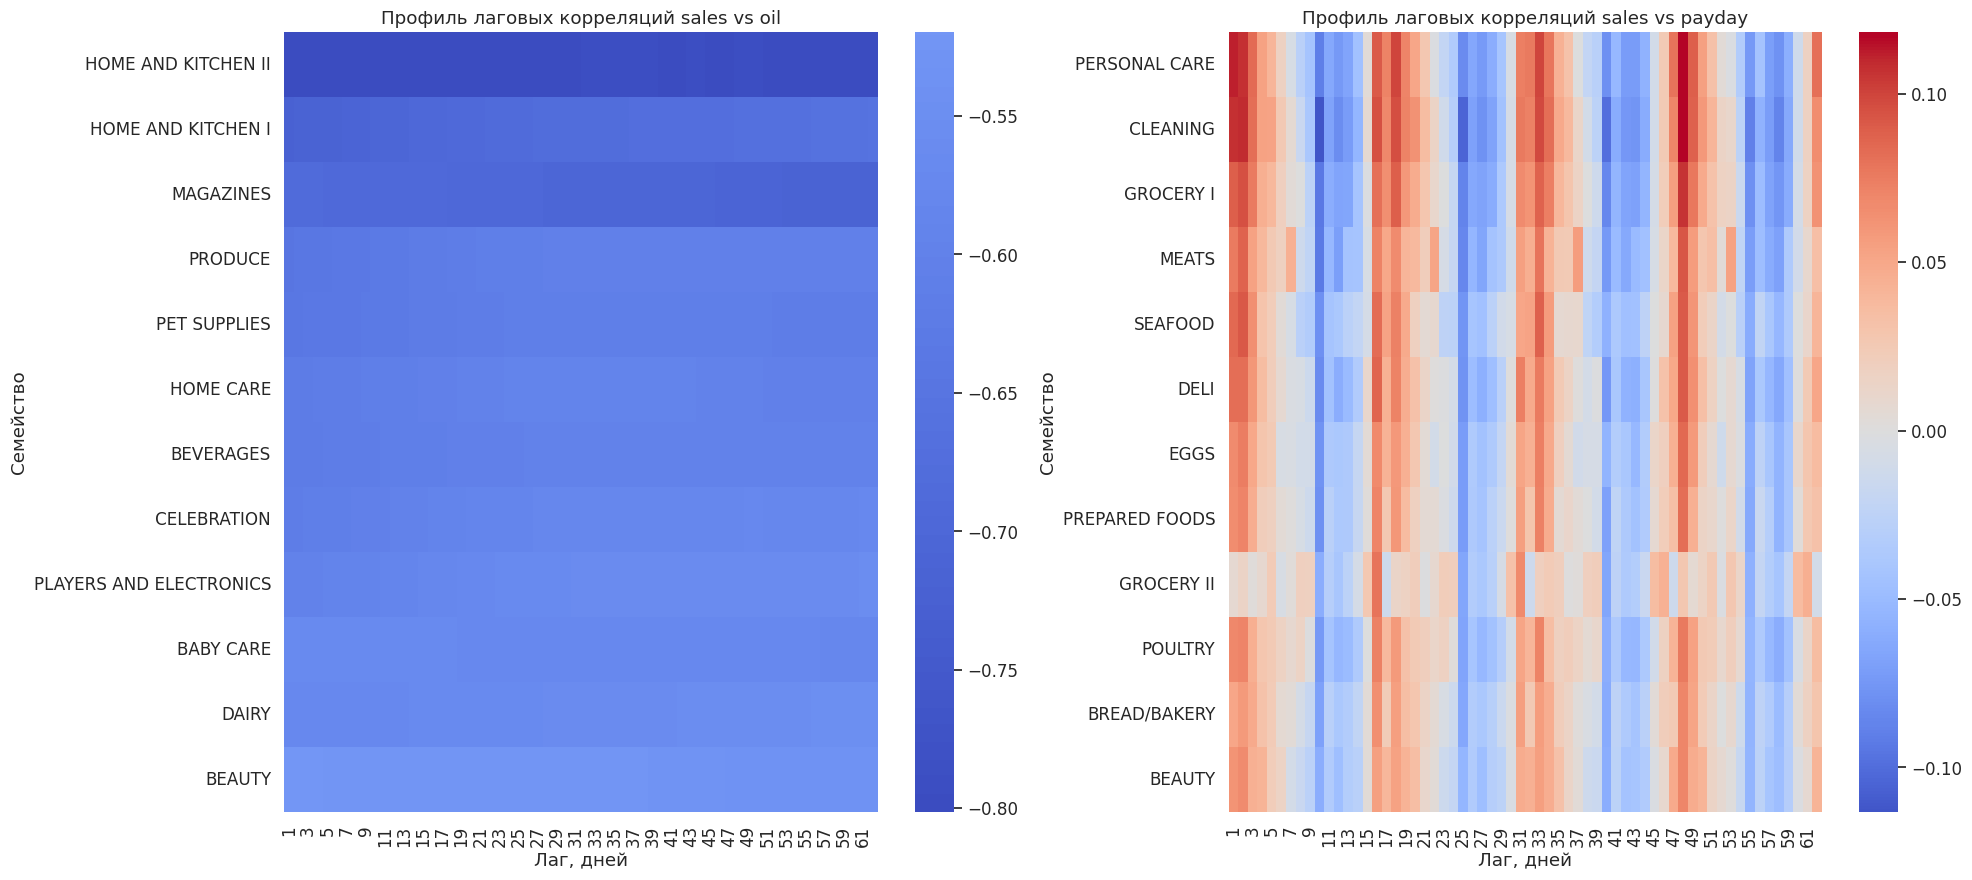

In [18]:
top_oil_families = oil_best.nlargest(12, 'best_oil_abs_corr')['family'].tolist()
top_payday_families = payday_best.nlargest(12, 'best_payday_abs_corr')['family'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(20, 9))
heatmap_specs = [
    ('dcoilwtico', top_oil_families, 'Профиль лаговых корреляций sales vs oil'),
    ('is_payday', top_payday_families, 'Профиль лаговых корреляций sales vs payday'),
]

for ax, (feature, families, title) in zip(axes, heatmap_specs):
    heatmap_data = (
        lag_scan[(lag_scan['feature'] == feature) & (lag_scan['family'].isin(families))]
        .pivot(index='family', columns='lag', values='corr')
        .reindex(families)
    )
    sns.heatmap(heatmap_data, cmap='coolwarm', center=0, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Лаг, дней')
    ax.set_ylabel('Семейство')

plt.tight_layout()
plt.show()


### Выводы по лаговым внешним факторам

Лаговый анализ действительно даёт более содержательную картину, чем простая корреляция день в день. Для нефти отрицательная связь с продажами после сдвига становится заметно сильнее,
причём у 17 из 33 семейств лучший лаг равен 1 дню. Для крупных и прикладно важных категорий величина связи уже выглядит не символической, а содержательной:
`BEVERAGES`, `PRODUCE`, `DAIRY`, `BREAD/BAKERY`, `GROCERY I`, `CLEANING` и `PERSONAL CARE` показывают лаговые корреляции порядка `-0.40 ... -0.65`.
Это не означает, что цена нефти буквально управляет спросом на следующий день; скорее, она отражает общий макроэкономический фон, инерцию потребительской среды и долгосрочный режим экономики,
который в агрегированном ритейле считывается лучше, чем в грубой корреляции без лагов.

При этом длинные «лучшие» лаги по нефти вроде 48, 61 или 62 дней для `MAGAZINES`, `BABY CARE`, `BEAUTY`, `MEATS` и части малых категорий нельзя трактовать буквально.
Здесь почти наверняка смешиваются тренд, сезонность, разреженность ряда и эффект выбора максимума по модулю из большого числа кандидатов. Поэтому нефть полезно понимать как слабый внешний фон,
который может немного помогать модели, но от которого не стоит ждать устойчивой причинной интерпретации и точного календарного механизма.

Для `is_payday` картина иная. Корреляция день в день почти везде близка к нулю, но по средним продажам payday-окно всё же даёт осмысленный uplift в категориях stock-up спроса.
Наиболее заметно это видно у `LIQUOR,WINE,BEER` (`+15.0%`), `GROCERY II` (`+5.8%`), `BABY CARE` (`+4.1%`), `DELI` (`+3.2%`), `PERSONAL CARE` (`+2.6%`),
`BREAD/BAKERY`, `DAIRY`, `HOME CARE` и `EGGS` (порядка `+2%`). Это важный экономический вывод: сам бинарный payday-флаг слишком груб, но в данных действительно есть поведение,
похожее на закупки после поступления зарплаты.

Характерно, что лучшие payday-лаги часто группируются около 10-16 и 46-48 дней. Интерпретировать это как реакцию «ровно через 48 дней» было бы ошибкой.
Гораздо правдоподобнее, что так проявляется месячный и полумесячный ритм закупок, который простой флаг `is_payday` улавливает лишь частично. Для модели отсюда следует практический вывод:
полезнее строить признаки расстояния до дня зарплаты, расстояния после него, индикаторы начала и конца месяца и короткие rolling-окна вокруг payday, чем полагаться только на один бинарный флаг.

`transactions` по-прежнему остаётся самым сильным описательным фактором: особенно высокие корреляции наблюдаются у `GROCERY I` (`0.763`), `GROCERY II` (`0.758`), `CLEANING` (`0.749`),
`DELI` (`0.720`) и `PREPARED FOODS` (`0.695`). Но по смыслу это почти прямой прокси магазинного трафика, а не внешний экзогенный драйвер спроса. Поскольку `transactions` отсутствует в test,
использовать его как честный прямой input нельзя; он остаётся либо исследовательским признаком, либо компонентой двухэтапной схемы с отдельным прогнозом трафика.

Самым прикладным внешним фактором в этом блоке выглядит `onpromotion`. Сильная связь видна у `SCHOOL AND OFFICE SUPPLIES` (`0.770`), `BREAD/BAKERY` (`0.622`), `BEVERAGES` (`0.601`),
`BEAUTY` (`0.560`) и `GROCERY I` (`0.510`). В отличие от нефти и `transactions`, это управляемый и доступный на горизонте прогноза сигнал, поэтому именно его стоит рассматривать как один из ключевых драйверов качества
в табличных моделях. Наконец, слабость агрегированного holiday-флага подтверждает, что разные события нельзя без потерь сводить к одному бинарному признаку: под ним смешиваются реальные праздники спроса,
закрытия магазинов, перенесённые даты и `Bridge`-дни. Значит, на следующем этапе лучше использовать более детализированную событийную разметку, а не только общий `is_holiday`.


### Как интерпретировать этот блок

Даже если какая-то связь выглядит заметной, это еще не означает причинность.
Но такой анализ помогает понять, что имеет смысл нести в модели,
а какие признаки, возможно, окажутся слишком слабыми или слишком проблемными в практической постановке.

Здесь особенно важно не перепутать объяснение с прогнозированием. На общей панели `onpromotion` действительно даёт содержательный сигнал
(корреляция с `sales` около 0.428) и при этом доступен на тестовом горизонте, поэтому это реальный кандидат в признаки модели.
С `transactions` ситуация принципиально другая: на уровне `store-date` связь с продажами очень сильная (около 0.855),
но экономически это почти не внешний фактор, а близкий прокси магазинного трафика, то есть ещё одно проявление текущего спроса.
Кроме того, `transactions` отсутствует в test, поэтому без отдельного прогноза этого ряда использовать его как прямой экзогенный признак нельзя.
Нефть показывает лишь слабую отрицательную связь (`-0.075`) и скорее задаёт макроэкономический фон, чем дневной драйвер спроса.
Флаги `is_holiday` и `is_payday` на уровне всей панели выглядят слабо, что не означает их бесполезность: для payday-дат средние продажи выше,
но эффект, по-видимому, локален и проявляется сильнее в отдельных категориях stock-up спроса, а не в среднем по всей сети.
Отдельно стоит помнить про событийные шоки: README прямо указывает на землетрясение 2016-04-16, и в данных действительно виден повышенный спрос
в ближайшие дни после него. Значит, описания событий и специальные даты могут быть важнее простых агрегированных holiday-флагов.


## 7. Анализ целевой переменной по категориям

Это один из центральных блоков EDA. Здесь нам важно понять,
какие товарные семейства формируют основной оборот, какие категории ведут себя стабильно,
а где наблюдаются редкие пики, сильная асимметрия, дробные значения и большое число нулей.

Именно отсюда потом появляются решения о логарифмировании,
выборе baseline-стратегий и ожиданиях от глобальных моделей.


In [19]:
family_stats = (
    train_processed.groupby('family')['sales']
    .agg(['mean', 'median', 'std', 'skew', 'min', 'max', 'sum'])
    .reset_index()
)
family_stats['coef_var'] = family_stats['std'] / family_stats['mean'].replace(0, np.nan)
family_stats = family_stats.sort_values('sum', ascending=False)
family_stats.head(15)


,family,mean,median,std,skew,min,max,sum,coef_var
12,GROCERY I,3768.021929,3179.839000,2876.669093,3.247206,0.0,124717.000,3.434627e+08,0.763443
3,BEVERAGES,2380.139613,1779.000000,2308.063115,2.346397,0.0,25413.000,2.169545e+08,0.969718
30,PRODUCE,1346.154606,393.936000,2184.874417,2.598156,0.0,17850.615,1.227047e+08,1.623049
7,CLEANING,1069.875472,937.000000,735.660731,1.504916,0.0,11377.000,9.752129e+07,0.687613
8,DAIRY,707.474427,519.000000,672.038137,1.872981,0.0,5636.000,6.448771e+07,0.949912
5,BREAD/BAKERY,462.238301,400.000000,368.499071,1.401269,0.0,4551.298,4.213395e+07,0.797206
28,POULTRY,349.701646,205.155505,400.399708,2.770006,0.0,12143.201,3.187600e+07,1.144975
24,MEATS,341.039894,224.295500,455.671242,83.582320,0.0,89576.360,3.108647e+07,1.336123
25,PERSONAL CARE,269.791678,222.000000,226.625241,3.047760,0.0,7504.000,2.459205e+07,0.840001
9,DELI,264.506785,218.213000,210.562609,1.885412,0.0,2118.325,2.411032e+07,0.796057


In [20]:
fractional_sales = np.sort(train_processed.loc[train_processed['sales'] % 1 != 0, 'family'].unique())
print('Категории с дробными продажами:', list(fractional_sales))


Категории с дробными продажами: ['BREAD/BAKERY', 'DELI', 'FROZEN FOODS', 'GROCERY I', 'MEATS', 'POULTRY', 'PREPARED FOODS', 'PRODUCE', 'SEAFOOD']


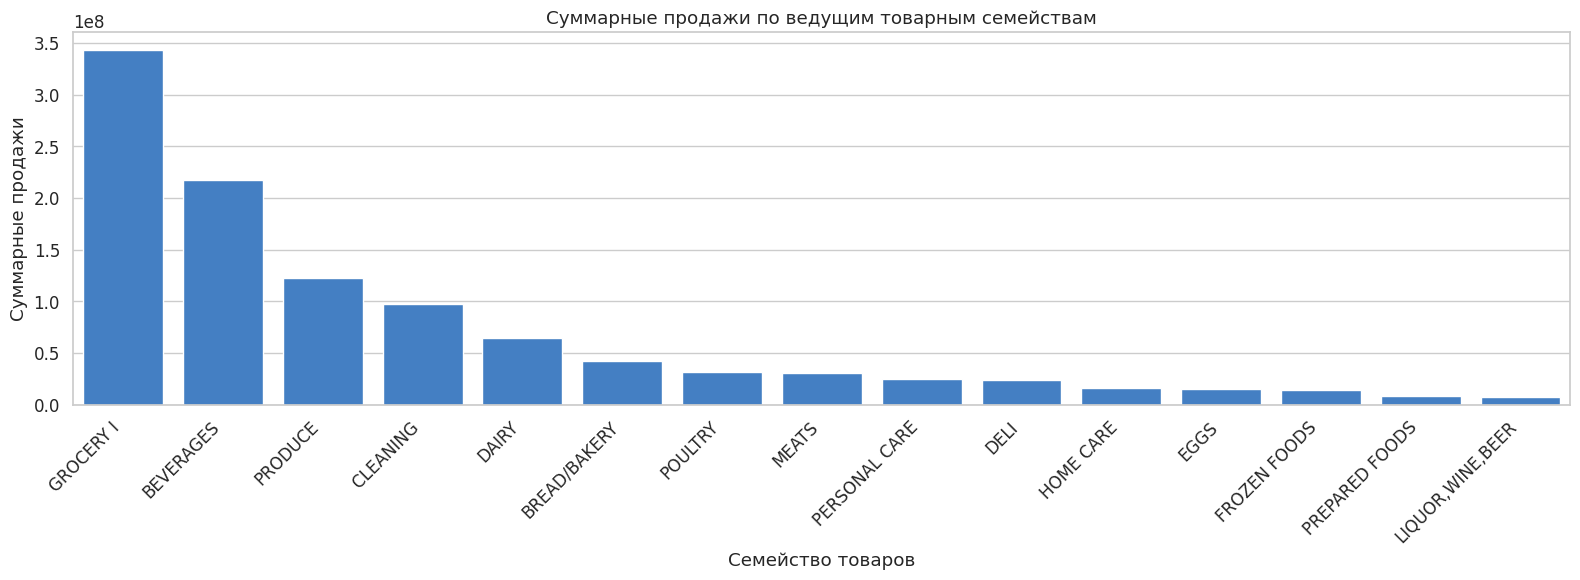

In [21]:
plt.figure(figsize=(16, 6))
top_families = family_stats.head(15)
sns.barplot(data=top_families, x='family', y='sum', color='#2f7ed8')
plt.title('Суммарные продажи по ведущим товарным семействам')
plt.xlabel('Семейство товаров')
plt.ylabel('Суммарные продажи')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [22]:
zero_sales = (
    train_processed.groupby(['store_nbr', 'family'], as_index=False)['sales']
    .sum()
    .query('sales == 0')
)
zero_sales.to_csv(DATASETS_DIR / 'zero_sales.csv', index=False)

zero_sales_by_family = (
    zero_sales.groupby('family').size().reset_index(name='n_zero_store_family_pairs')
    .sort_values('n_zero_store_family_pairs', ascending=False)
)
zero_sales_by_family.head(15)


,family,n_zero_store_family_pairs
1,BOOKS,28
0,BABY CARE,12
2,LADIESWEAR,10
3,LAWN AND GARDEN,3


### Промежуточный вывод по категориям товаров

После выполнения этого блока полезно зафиксировать,
какие семейства оказываются ключевыми по обороту, какие категории наиболее нестабильны
и насколько заметна проблема нулевых или дробных продаж.

По распределению продаж категории сильно неоднородны, и это один из главных содержательных выводов всего EDA.
Основной оборот формируют крупные продовольственные семейства `GROCERY I`, `BEVERAGES`, `PRODUCE`, `CLEANING` и `DAIRY`,
причём для лидеров медианы заметно ниже средних, что указывает на правую асимметрию и наличие пиков спроса. Многие малые категории,
например `BOOKS`, `SCHOOL AND OFFICE SUPPLIES`, `BABY CARE`, живут в режиме редкого и прерывистого спроса, где среднее плохо описывает типичное поведение.
Это аргумент в пользу робастных метрик, лог-преобразований и осторожной интерпретации средних значений.
Дробные продажи наблюдаются прежде всего в весовых продовольственных категориях, что согласуется с предметной областью и подтверждает корректность данных.
Наконец, 53 пары `(store_nbr, family)` имеют нулевую суммарную продажу за весь период, а значит ассортимент по магазинам неодинаков:
часть рядов нужно трактовать как структурно отсутствующие, а не как просто "очень слабые". Это особенно важно для моделей,
которые хотят переносить информацию между магазинами или кластерами.


### Расширенный анализ временной структуры по семействам

Дальше мы переходим от описательных статистик к динамике самих рядов.
Задача блока ниже: проверить доминирующие периоды, выделить тренд, оценить выбросы и понять,
насколько разные товарные семейства действительно живут в недельном, месячном или событийном ритме.


In [23]:
def safe_relative_change(current, baseline):
    if pd.isna(current) or pd.isna(baseline) or baseline == 0:
        return np.nan
    return 100 * (current / baseline - 1)


def detect_seasonality_period(series, max_lag=120, min_strength=0.25):
    clean = pd.Series(series).dropna()
    if len(clean) < 30:
        return pd.NA

    nlags = min(max_lag, len(clean) - 1)
    autocorr = acf(clean, nlags=nlags, fft=True)
    autocorr[0] = 0

    best_period = int(np.argmax(autocorr))
    if best_period <= 1 or autocorr[best_period] < min_strength:
        return pd.NA

    return best_period


def extract_trend(series, period):
    clean_series = pd.Series(series).astype(float)
    if pd.notna(period) and int(period) >= 2 and len(clean_series) >= int(period) * 2:
        trend = seasonal_decompose(
            clean_series,
            model='additive',
            period=int(period),
            extrapolate_trend='freq',
        ).trend
    else:
        trend = clean_series.rolling(28, min_periods=7, center=True).mean()

    return trend.ffill().bfill()


temporal_rows = []
for family, family_frame in family_daily_external.groupby('family'):
    ordered = family_frame.sort_values('date').set_index('date').asfreq('D', fill_value=0)
    sales = ordered['sales']
    dominant_period = detect_seasonality_period(sales)
    trend = extract_trend(sales, dominant_period)

    sales_std = sales.std(ddof=0)
    if sales_std == 0 or pd.isna(sales_std):
        z_score = pd.Series(0.0, index=sales.index)
    else:
        z_score = (sales - sales.mean()) / sales_std

    outlier_mask = z_score.abs() > 3

    temporal_rows.append({
        'family': family,
        'total_sales': sales.sum(),
        'dominant_period': dominant_period,
        'acf_lag_7': sales.autocorr(7),
        'acf_lag_14': sales.autocorr(14),
        'acf_lag_28': sales.autocorr(28),
        'trend_growth_pct': safe_relative_change(trend.tail(90).mean(), trend.head(90).mean()),
        'outlier_days': int(outlier_mask.sum()),
        'outlier_share_pct': 100 * outlier_mask.mean(),
        'zero_day_share_pct': 100 * (sales == 0).mean(),
        'holiday_uplift_pct': safe_relative_change(
            ordered.loc[ordered['is_holiday'] == 1, 'sales'].mean(),
            ordered.loc[ordered['is_holiday'] == 0, 'sales'].mean(),
        ),
        'earthquake_uplift_pct': safe_relative_change(
            ordered.loc['2016-04-17':'2016-04-24', 'sales'].mean(),
            ordered.loc['2016-04-03':'2016-04-15', 'sales'].mean(),
        ),
    })

family_temporal_summary = (
    pd.DataFrame(temporal_rows)
    .merge(
        lagged_external_summary[[
            'family',
            'best_oil_lag',
            'best_oil_corr',
            'best_payday_lag',
            'best_payday_corr',
        ]],
        on='family',
        how='left',
    )
    .sort_values('total_sales', ascending=False)
)

family_temporal_summary.head(15).round(3)


,family,total_sales,dominant_period,acf_lag_7,acf_lag_14,acf_lag_28,trend_growth_pct,outlier_days,outlier_share_pct,zero_day_share_pct,holiday_uplift_pct,earthquake_uplift_pct,best_oil_lag,best_oil_corr,best_payday_lag,best_payday_corr
12,GROCERY I,3.434627e+08,7,0.686,0.672,0.655,77.841,26,1.540,0.237,-0.963,77.826,6,-0.483,48,0.106
3,BEVERAGES,2.169545e+08,7,0.882,0.843,0.785,245.434,3,0.178,0.237,-1.501,55.658,1,-0.623,10,-0.049
30,PRODUCE,1.227047e+08,7,0.911,0.844,0.720,313867.968,0,0.000,4.621,-5.775,2.600,1,-0.646,10,-0.028
7,CLEANING,9.752129e+07,28,0.625,0.599,0.680,48.337,22,1.303,0.237,-1.426,31.070,8,-0.408,48,0.117
8,DAIRY,6.448771e+07,7,0.875,0.846,0.840,166.284,4,0.237,0.237,-1.839,8.509,1,-0.575,48,0.062
5,BREAD/BAKERY,4.213395e+07,7,0.838,0.801,0.798,62.063,17,1.007,0.237,-2.685,18.676,1,-0.529,48,0.070
28,POULTRY,3.187600e+07,7,0.821,0.784,0.787,109.637,10,0.592,0.237,1.779,8.105,1,-0.399,48,0.076
24,MEATS,3.108647e+07,7,0.520,0.478,0.510,18.511,13,0.770,0.237,2.579,4.532,62,-0.148,10,-0.093
25,PERSONAL CARE,2.459205e+07,28,0.660,0.652,0.730,69.533,17,1.007,0.237,1.150,86.494,7,-0.461,48,0.118
9,DELI,2.411032e+07,7,0.784,0.748,0.774,66.739,16,0.948,0.237,1.026,5.762,1,-0.508,48,0.091


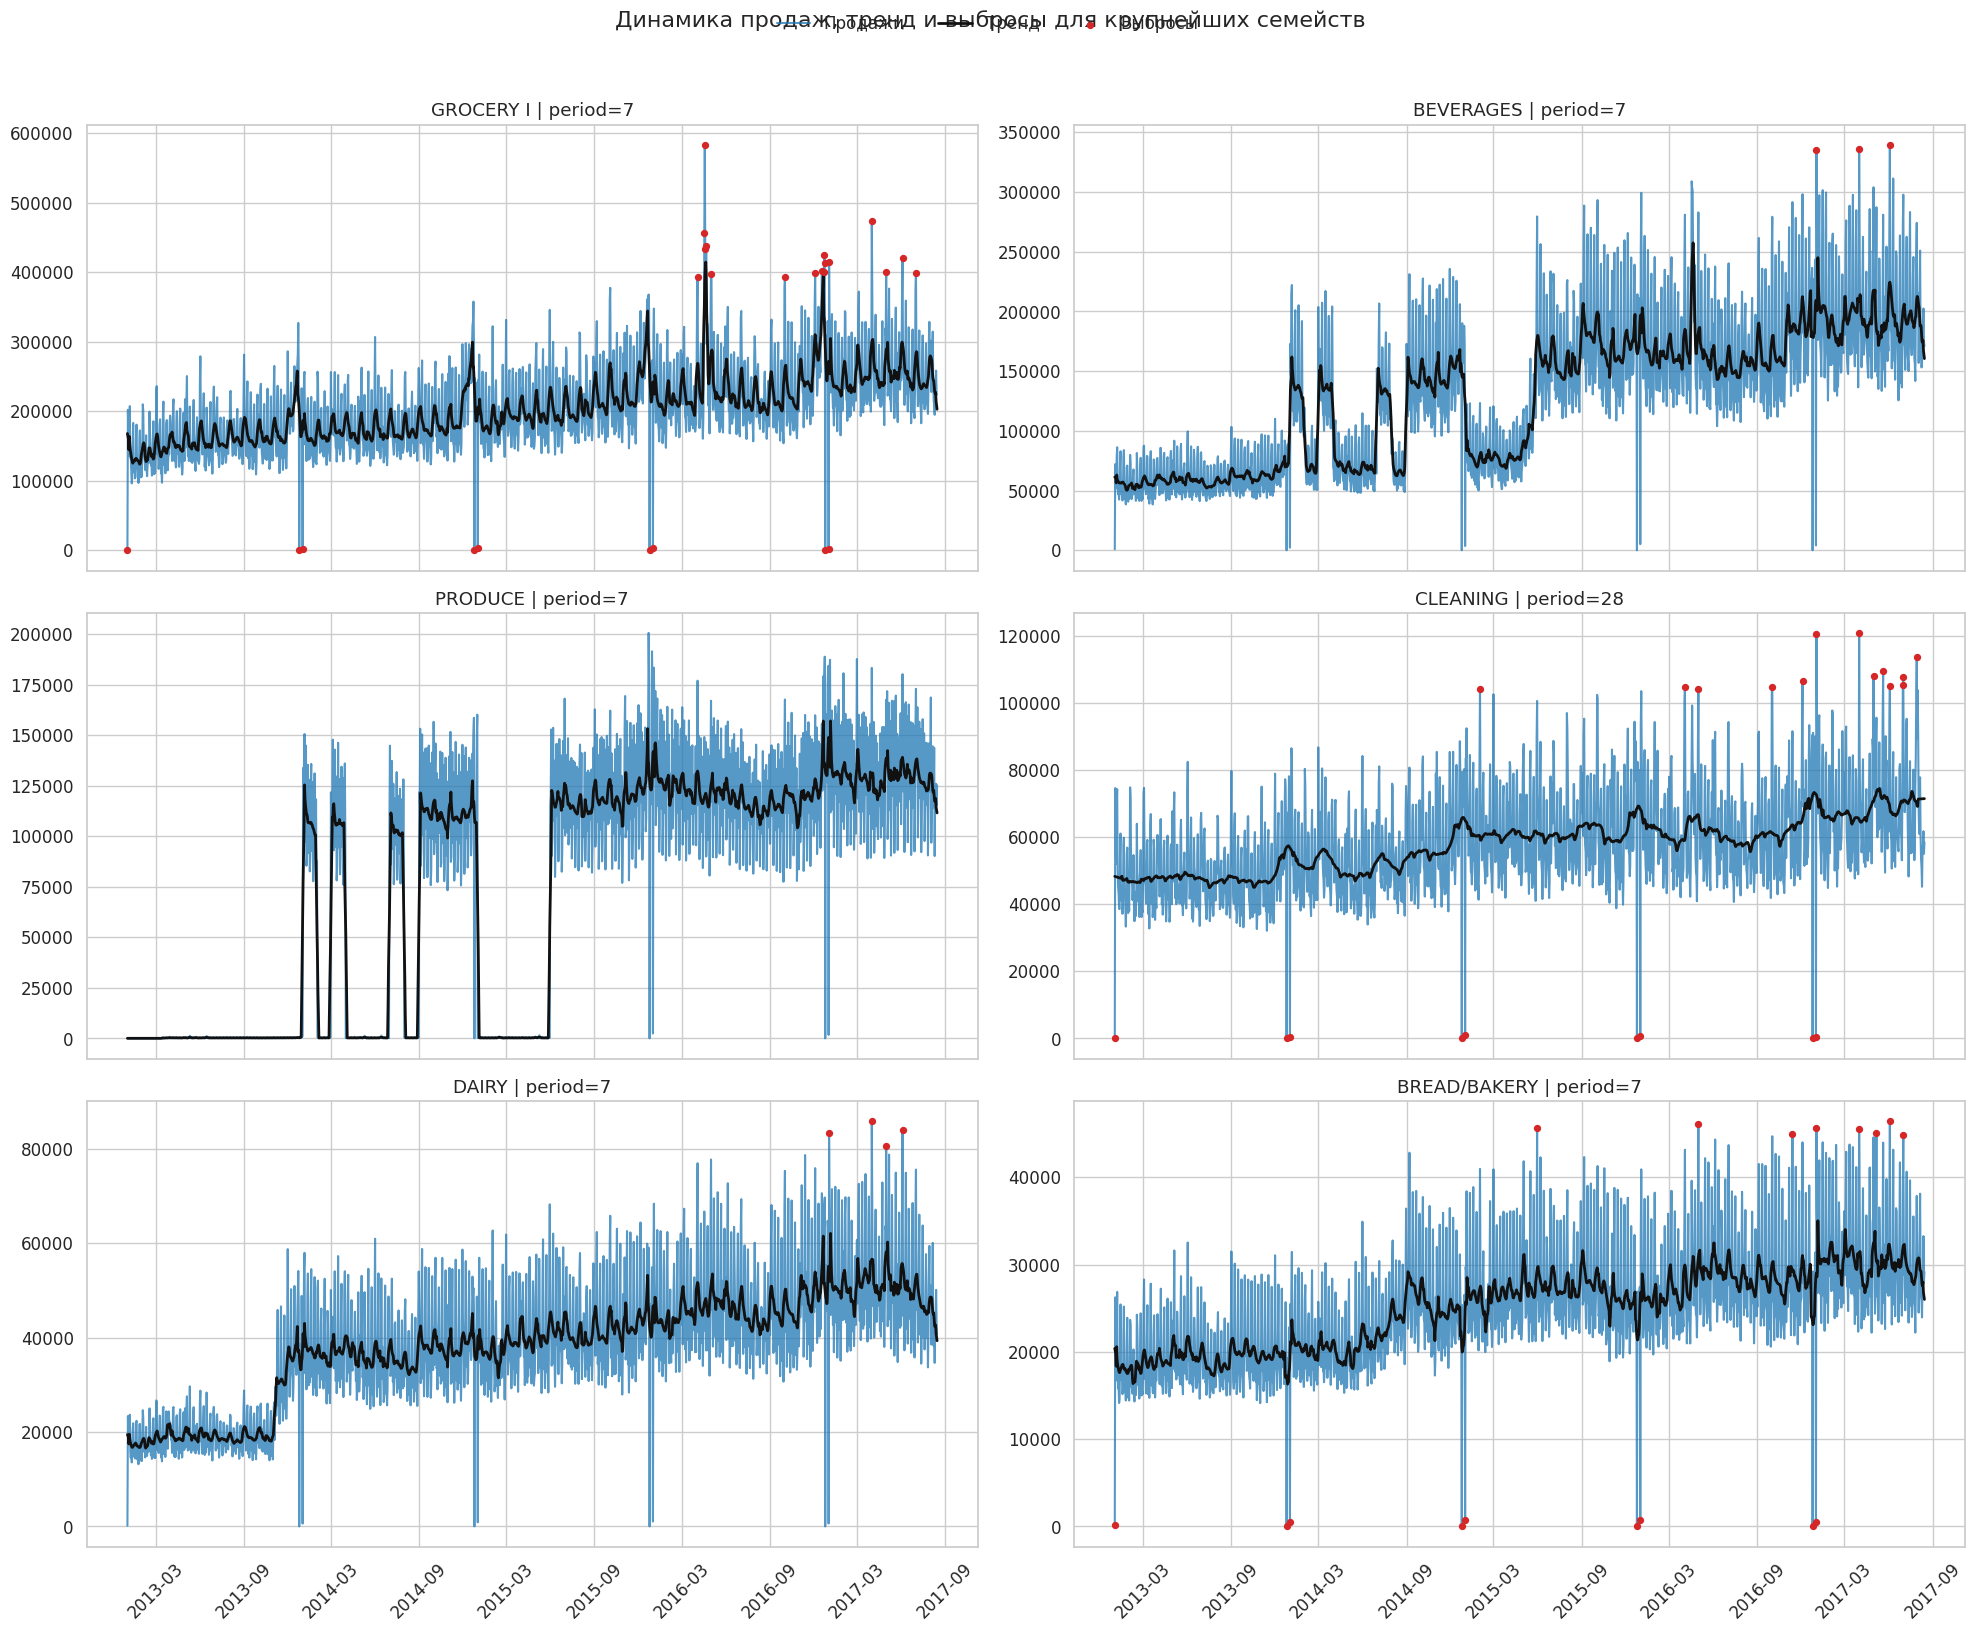

In [24]:
top_temporal_families = family_temporal_summary.head(6)['family'].tolist()

fig, axes = plt.subplots(3, 2, figsize=(20, 16), sharex=True)
axes = axes.flatten()

for ax, family in zip(axes, top_temporal_families):
    ordered = (
        family_daily_external[family_daily_external['family'] == family]
        .sort_values('date')
        .set_index('date')
        .asfreq('D', fill_value=0)
    )
    period = family_temporal_summary.loc[family_temporal_summary['family'] == family, 'dominant_period'].iloc[0]
    trend = extract_trend(ordered['sales'], period)

    sales_std = ordered['sales'].std(ddof=0)
    if sales_std == 0 or pd.isna(sales_std):
        z_score = pd.Series(0.0, index=ordered.index)
    else:
        z_score = (ordered['sales'] - ordered['sales'].mean()) / sales_std
    outliers = ordered[z_score.abs() > 3]

    ax.plot(ordered.index, ordered['sales'], label='Продажи', color='#1f77b4', alpha=0.75)
    ax.plot(trend.index, trend, label='Тренд', color='#111111', linewidth=2)
    ax.scatter(outliers.index, outliers['sales'], color='#d62728', s=18, label='Выбросы', zorder=5)
    ax.set_title(f'{family} | period={period}')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    ax.tick_params(axis='x', rotation=45)

for ax in axes[len(top_temporal_families):]:
    ax.axis('off')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False)
fig.suptitle('Динамика продаж, тренд и выбросы для крупнейших семейств', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()


### Выводы по временной динамике

Расширенный анализ временной структуры подтверждает, что главный ритм данных — недельный. У большинства крупных семейств `dominant_period = 7`, а для 23 из 33 категорий автокорреляция на лаге 7 превышает `0.7`.
Особенно сильна недельная повторяемость у `PET SUPPLIES`, `PRODUCE`, `HOME AND KITCHEN II`, `BEVERAGES`, `DAIRY`, `MAGAZINES`, `BREAD/BAKERY`, `POULTRY` и `EGGS`.
Это важный практический вывод: день недели, лаги 7 и 14, а также rolling-агрегаты по недельному окну должны считаться базовыми признаками почти для любой модели в этой задаче.

Одновременно недельный ритм не исчерпывает всю структуру спроса. Для `CLEANING` и `PERSONAL CARE` алгоритм явно выделяет период 28 дней, а высокая автокорреляция на лаге 28 наблюдается также у `DAIRY`, `MAGAZINES`,
`BREAD/BAKERY`, `EGGS`, `POULTRY` и ряда других семейств. Это хорошо согласуется с гипотезой о более редких household-закупках и stock-up поведении: поверх недельной сезонности в данных есть и более длинный,
почти месячный цикл. Поэтому признаки положения внутри месяца и более длинные лаги тоже имеют экономический смысл. Важно и то, что отсутствие явного `dominant_period` у отдельных рядов, например `HOME CARE` или `FROZEN FOODS`,
не означает отсутствия сезонности вообще: в таких случаях детектор просто оказывается более консервативным, чем сама автокорреляционная структура ряда.

По тренду данные далеки от стационарности. Крупные семейства демонстрируют заметный рост уровня продаж: `GROCERY I` (`+77.8%`), `DAIRY` (`+166.3%`), `POULTRY` (`+109.6%`), `CLEANING` (`+48.3%`),
`BREAD/BAKERY` (`+62.1%`), а для `BEVERAGES` оценка ещё выше. Это означает, что модели должны уметь работать не только с сезонностью, но и с меняющимся уровнем ряда. При этом экстремальные величины вроде `PRODUCE`
с ростом порядка `313867%` нельзя трактовать буквально: здесь влияние почти наверняка оказывают очень низкая база в начале ряда и нестабильность самой процедуры выделения тренда. Такие значения полезны как сигнал нестационарности,
но не как предмет прямой экономической интерпретации.

Отдельно видно, насколько неоднородны ряды по выбросам и прерывистости. Наиболее тяжёлые хвосты и выраженные всплески наблюдаются у `FROZEN FOODS` (`2.25%` дней-выбросов), `LIQUOR,WINE,BEER` (`1.36%`), `CLEANING` (`1.30%`),
`EGGS` (`1.13%`), `PERSONAL CARE` и `BREAD/BAKERY` (около `1%`), а у `GROCERY I` таких дней просто много в абсолютном выражении (`26`). Это означает, что среднее значение и стандартная линейная интуиция описывают спрос не везде хорошо;
нужны либо лог-преобразования, либо робастные потери, либо признаки событий и акций, объясняющие пики. По прерывистости картина ещё жёстче: `BOOKS` живёт с нулём примерно в `83%` дней, `BABY CARE` — в `47%`,
`SCHOOL AND OFFICE SUPPLIES`, `LADIESWEAR`, `PLAYERS AND ELECTRONICS` и `HOME CARE` — примерно в `38-40%`. Такие ряды нельзя анализировать и моделировать так же, как крупные стабильные продуктовые категории.

Праздничный эффект оказывается гораздо сложнее простого тезиса «в праздники продажи выше». Для многих крупных продовольственных семейств holiday uplift даже отрицателен: например, у `PRODUCE`, `BREAD/BAKERY`, `BEVERAGES` и `GROCERY I`.
Это не противоречит здравому смыслу, а показывает, что общий `is_holiday` смешивает очень разные режимы: предпраздничные закупки, сами праздничные даты, закрытия магазинов, переносы и локальные события. Положительный holiday uplift заметнее у `LIQUOR,WINE,BEER`,
`MEATS`, `POULTRY`, `PERSONAL CARE`, `DELI` и `EGGS`, то есть там, где действительно можно ожидать либо праздничного потребления, либо подготовки к нему. Следовательно, для качественной модели нужен не единый holiday-флаг,
а более подробная кодировка типа, локальности и роли события относительно даты прогноза.

Очень сильный сигнал даёт окно после землетрясения 2016-04-16. Особенно заметен post-event uplift у `PERSONAL CARE` (`+86.5%`), `GROCERY I` (`+77.8%`), `HOME CARE` (`+69.0%`), `BEVERAGES` (`+55.7%`), `MAGAZINES` (`+55.9%`) и `CLEANING` (`+31.1%`),
а для некоторых малых категорий всплеск ещё выше. Это уже не похоже на случайный шум; данные действительно содержат событийный шок, влияющий на спрос широкого круга товаров. Значит, в feature engineering есть прямой смысл использовать event-флаги,
окна до и после крупных событий, а также отдельные признаки для аномальных периодов. В сумме этот блок подсказывает архитектуру будущих признаков довольно явно: нужны лаги 1/7/14/28, rolling-средние и rolling-std,
позиция внутри недели и месяца, более богатая holiday/event-разметка и, по возможности, специальные стратегии для прерывистых категорий.


## 8. Пространственная структура спроса и похожесть магазинов

До этого момента мы в основном смотрели на товары и календарь.
Теперь имеет смысл переключиться на саму сеть магазинов и понять,
насколько магазины похожи между собой, что видно по городам, типам магазинов и кластерам,
и есть ли основания говорить о переносимой структуре спроса.


In [25]:
city_family_stats = (
    train_processed.groupby(['city', 'family'])['sales']
    .agg(['mean', 'median', 'std', 'skew'])
    .reset_index()
    .sort_values('median', ascending=False)
)
store_type_family_stats = (
    train_processed.groupby(['store_type', 'family'])['sales']
    .agg(['mean', 'median', 'std', 'skew'])
    .reset_index()
    .sort_values('median', ascending=False)
)
cluster_family_stats = (
    train_processed.groupby(['cluster', 'family'])['sales']
    .agg(['mean', 'median', 'std', 'skew'])
    .reset_index()
    .sort_values('median', ascending=False)
)

city_family_stats.head(10), store_type_family_stats.head(10), cluster_family_stats.head(10)


(           city     family         mean     median          std      skew
 78      Cayambe  GROCERY I  6543.215911  6137.6690  2098.685554  1.217047
 606       Quito  GROCERY I  5505.370032  4636.8870  3652.765067  3.175533
 45     Babahoyo  GROCERY I  3914.587342  3645.4700  1548.902415  4.736968
 69      Cayambe  BEVERAGES  3637.027844  3539.0000  1295.264409  0.442992
 441     Machala  GROCERY I  3603.631794  3398.5000  1475.323367  0.846130
 408        Loja  GROCERY I  3752.404037  3393.5000  1212.890461  1.218030
 111      Cuenca  GROCERY I  3094.300223  3354.6805  1882.506577  0.034680
 12       Ambato  GROCERY I  3987.409744  3273.0000  2435.721108  0.920275
 375    Libertad  GROCERY I  3185.443639  3188.1540  1422.462140  0.026567
 210  Esmeraldas  GROCERY I  3289.259757  3143.9510  1095.696801  0.804406,
     store_type     family         mean      median          std      skew
 12           A  GROCERY I  6951.242248  6536.50000  4081.809033  0.971453
 3            A  BEVERAG

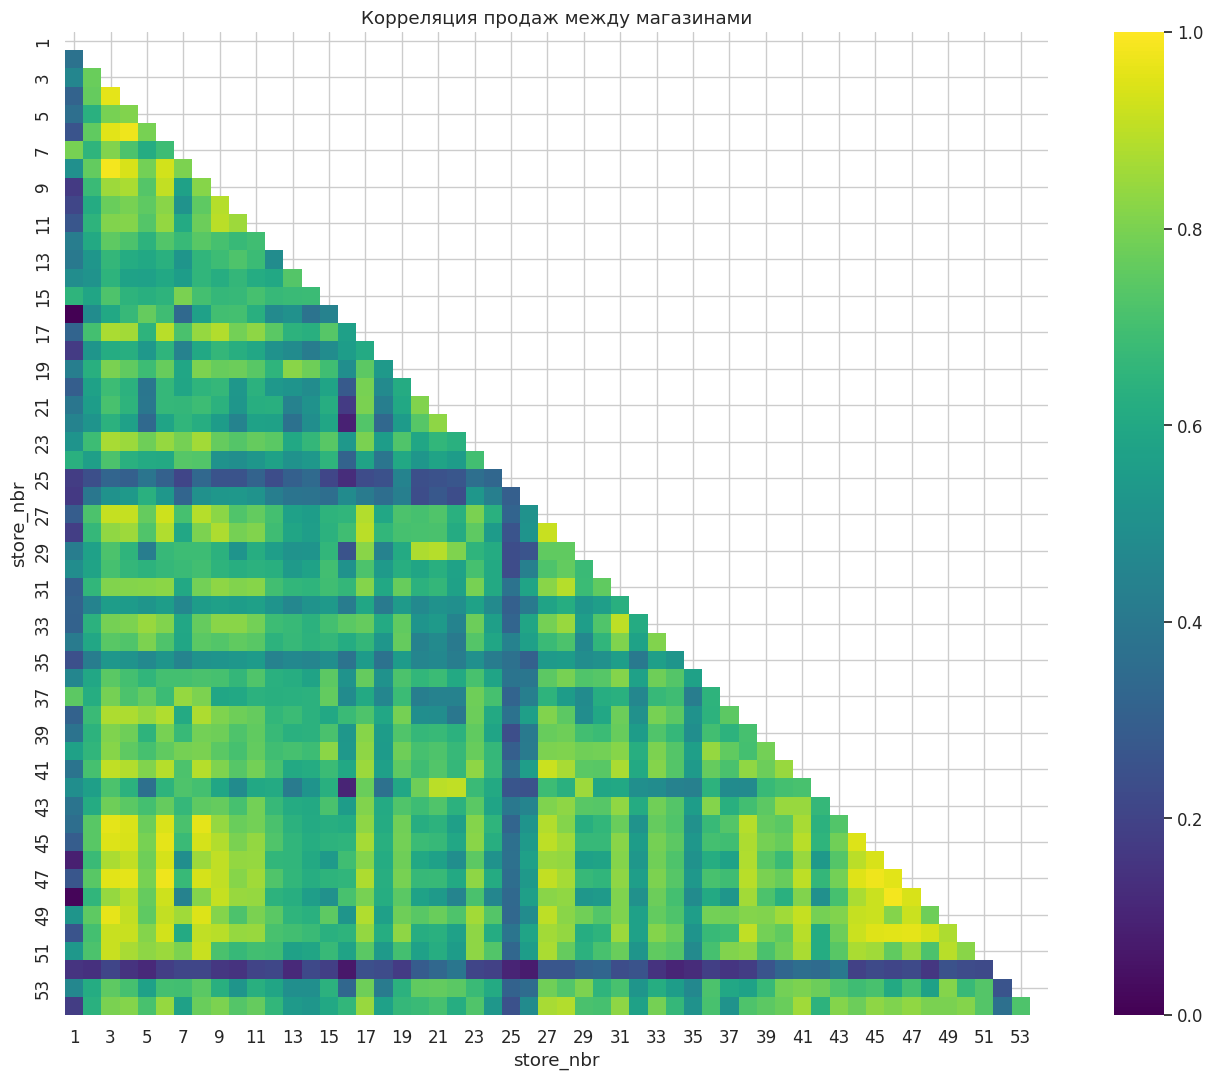

In [26]:
store_daily_sales = (
    train_processed.groupby(['date', 'store_nbr'])['sales']
    .sum()
    .reset_index()
    .pivot(index='date', columns='store_nbr', values='sales')
)
store_corr = store_daily_sales.corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(store_corr, dtype=bool))
sns.heatmap(store_corr, mask=mask, cmap='viridis', vmin=0, vmax=1, square=True, cbar=True)
plt.title('Корреляция продаж между магазинами')
plt.tight_layout()
plt.show()


In [27]:
store_cluster_map = train_processed.groupby('store_nbr')['cluster'].first().reset_index()
cluster_corr_rows = []
for cluster in sorted(store_cluster_map['cluster'].unique()):
    stores_in_cluster = store_cluster_map.loc[store_cluster_map['cluster'] == cluster, 'store_nbr']
    cluster_corr = store_corr.loc[stores_in_cluster, stores_in_cluster]
    mean_corr = cluster_corr.where(~np.eye(len(stores_in_cluster), dtype=bool)).mean().mean()
    cluster_corr_rows.append({'cluster': cluster, 'mean_store_corr': mean_corr})
cluster_corr_df = pd.DataFrame(cluster_corr_rows).sort_values('mean_store_corr', ascending=False)
cluster_corr_df


,cluster,mean_store_corr
13,14,0.953991
7,8,0.865613
8,9,0.849909
3,4,0.828010
14,15,0.683932
5,6,0.680771
9,10,0.672195
2,3,0.605963
12,13,0.527759
6,7,0.490326


### Промежуточный вывод по структуре сети

Здесь стоит коротко отметить,
поддерживают ли результаты гипотезу о сходстве магазинов и кластеров,
или же между ними слишком много неоднородности для уверенных обобщений.

По структуре сети виден важный компромисс между общностью и локальной спецификой. В среднем магазины действительно движутся похоже:
средняя попарная корреляция дневных продаж около 0.637, медианная около 0.662. Это означает, что глобальные тренды и общий календарный ритм сети существуют.
Но кластеры неоднородны по качеству внутренней связанности: есть почти синхронные группы, например кластеры 14, 8, 9 и 4,
а есть заметно более рыхлые объединения. Следовательно, кластер можно использовать как полезный контекстный признак,
но не как достаточную единицу моделирования сам по себе. Для части магазинов перенос информации внутри кластера оправдан,
для части приведёт к огрублению локальной динамики. Это хорошо согласуется и с наблюдением из исходного EDA,
что одна модель на тип магазина или кластер без дополнительных признаков может терять важные различия в ассортименте и уровне спроса.


## 9. Сохраняем результаты подготовки данных

Разведочный анализ на этом этапе должен закончиться не только наблюдениями,
но и конкретным набором подготовленных таблиц, с которыми затем будут работать модели.

Поэтому здесь мы фиксируем временные сплиты и выделяем наиболее значимые серии,
чтобы дальнейшее сравнение моделей шло по одному и тому же протоколу.


In [28]:
def generate_time_splits(
    df,
    n_splits=3,
    horizon_days=16,
    step_days=30,
    date_col='date',
    last_val_end=None,
):
    ordered = df.sort_values(date_col).copy()
    unique_dates = ordered[date_col].drop_duplicates().sort_values().to_numpy()
    last_val_end = pd.to_datetime(unique_dates[-1] if last_val_end is None else last_val_end)
    splits = []
    for k in range(n_splits):
        val_end = last_val_end - pd.Timedelta(days=step_days * k)
        val_start = val_end - pd.Timedelta(days=horizon_days - 1)
        train_end = val_start - pd.Timedelta(days=1)
        train_idx = ordered.index[ordered[date_col] <= train_end]
        val_idx = ordered.index[(ordered[date_col] >= val_start) & (ordered[date_col] <= val_end)]
        if len(train_idx) == 0 or len(val_idx) == 0:
            continue
        splits.append({
            'name': f'split_{k + 1}',
            'train_idx': train_idx.tolist(),
            'val_idx': val_idx.tolist(),
            'train_end': str(pd.to_datetime(train_end).date()),
            'val_start': str(pd.to_datetime(val_start).date()),
            'val_end': str(pd.to_datetime(val_end).date()),
        })
    return splits

splits = generate_time_splits(train_processed, n_splits=3, horizon_days=16, step_days=30)
with open(METADATA_DIR / 'splits.json', 'w', encoding='utf-8') as f:
    json.dump(splits, f, indent=2, ensure_ascii=False)

series_sales = (
    train_processed.groupby(['store_nbr', 'family'])['sales']
    .sum()
    .rename('sales_sum')
    .reset_index()
)
series_sales['sales_share'] = series_sales['sales_sum'] / series_sales['sales_sum'].sum()
quantile_cut = series_sales['sales_sum'].quantile(0.8)
top_pairs_df = series_sales[series_sales['sales_sum'] >= quantile_cut].copy()
top_pairs_df.to_csv(DATASETS_DIR / 'top_pairs.csv', index=False)

pd.DataFrame(splits), top_pairs_df.head()


(      name                                          train_idx                                            val_idx   train_end   val_start  \
 0  split_1  [0, 469264, 2481360, 470952, 2479672, 472640, ...  [2277096, 1417904, 2694032, 1416216, 243056, 1...  2017-07-30  2017-07-31   
 1  split_2  [0, 469264, 2481360, 470952, 2479672, 472640, ...  [156938, 2798658, 2705818, 1897266, 1995170, 1...  2017-06-30  2017-07-01   
 2  split_3  [0, 469264, 2481360, 470952, 2479672, 472640, ...  [739268, 1976572, 1330068, 2439084, 1696364, 2...  2017-05-31  2017-06-01   
 
       val_end  
 0  2017-08-15  
 1  2017-07-16  
 2  2017-06-16  ,
     store_nbr        family     sales_sum  sales_share
 3           1     BEVERAGES  2.673769e+06     0.002490
 5           1  BREAD/BAKERY  5.699922e+05     0.000531
 7           1      CLEANING  1.078525e+06     0.001005
 8           1         DAIRY  1.054354e+06     0.000982
 12          1     GROCERY I  3.743823e+06     0.003487)

In [29]:
created_artifacts = pd.DataFrame([
    {'artifact': 'train_processed', 'path': str(DATASETS_DIR / 'train_processed.csv')},
    {'artifact': 'test_processed', 'path': str(DATASETS_DIR / 'test_processed.csv')},
    {'artifact': 'zero_sales', 'path': str(DATASETS_DIR / 'zero_sales.csv')},
    {'artifact': 'top_pairs', 'path': str(DATASETS_DIR / 'top_pairs.csv')},
    {'artifact': 'splits', 'path': str(METADATA_DIR / 'splits.json')},
])
created_artifacts


,artifact,path
0,train_processed,/home/jupyter/project/demand_forecasting/artif...
1,test_processed,/home/jupyter/project/demand_forecasting/artif...
2,zero_sales,/home/jupyter/project/demand_forecasting/artif...
3,top_pairs,/home/jupyter/project/demand_forecasting/artif...
4,splits,/home/jupyter/project/demand_forecasting/artif...


### Итог по EDA и следующий шаг

Если все таблицы успешно собраны, значит этот этап выполнил свою главную задачу:
мы не просто посмотрели на данные, а поняли их структуру и подготовили единую основу для дальнейших экспериментов.

Содержательно EDA дал несколько опорных выводов для всего проекта.
Во-первых, задача является панельной и иерархической: здесь одновременно важны календарь, магазин, семейство товара и специальные события,
поэтому ни один слишком грубый уровень агрегирования не выглядит универсально безопасным.
Во-вторых, перед моделированием обязательно нужно восстанавливать полную панель, иначе мы теряем неявные нулевые наблюдения и искажаем лаговую структуру.
В-третьих, в данных отчётливо присутствуют недельная, местами месячная и годовая сезонности, а также тренды и событийные всплески,
поэтому у моделей есть основания использовать лаги, rolling-признаки, календарные индикаторы и, в статистическом классе, сезонные компоненты.
В-четвёртых, признаки нужно делить не только по силе сигнала, но и по их доступности в момент прогноза: `onpromotion` и календарь выглядят прикладно полезными,
нефть может играть роль дополнительного фонового фактора, а `transactions` остаётся скорее исследовательским или двухэтапным признаком, но не честным прямым input для test.
В-пятых, спрос крайне неоднороден по категориям и магазинам: есть крупные устойчивые семейства, есть прерывистый спрос, есть структурно нулевые пары,
а также событийные всплески вроде постземлетрясной динамики. После такого EDA переход к baseline-моделям уже опирается не на формальную подготовку,
а на понятную экономическую и статистическую картину данных.
